In [1]:
# ============================
# Task 1: Data Quality Check
# ============================
import pandas as pd

df = pd.read_csv("Stady.csv", sep=';')

print("=== Task 1: Data Quality Check ===")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows count:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nExplanation:")
print("Task 1 identifies data quality issues such as missing values, duplicate rows, and incorrect data types.")

=== Task 1: Data Quality Check ===

First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none        72.0           72.0           74.0  
1               completed        69.0           90.0           88.0  
2                    none        90.0           95.0           93.0  
3                    none        47.0           57.0            NaN  
4                    none        76.0           78.0           75.0  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 

In [2]:
# ============================
# Task 2: Handle Missing Values
# ============================
print("\n=== Task 2: Handle Missing Values ===")

df_task2 = df.copy()

num_cols = ['math score', 'reading score', 'writing score']
cat_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

# Fill numerical missing values with mean
for col in num_cols:
    df_task2[col] = df_task2[col].fillna(df_task2[col].mean())

# Fill categorical missing values with mode
for col in cat_cols:
    df_task2[col] = df_task2[col].fillna(df_task2[col].mode()[0])

print("\nMissing values after imputation:")
print(df_task2.isnull().sum())

print("\nExplanation:")
print("Task 2 handles missing values by filling numerical columns with mean (good for small missing data) "
      "and categorical columns with mode (most common category). This ensures no data is lost while keeping dataset integrity.")


=== Task 2: Handle Missing Values ===

Missing values after imputation:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Explanation:
Task 2 handles missing values by filling numerical columns with mean (good for small missing data) and categorical columns with mode (most common category). This ensures no data is lost while keeping dataset integrity.


In [3]:
# ============================
# Task 3: Detect & Handle Outliers using IQR
# ============================
print("\n=== Task 3: Detect & Handle Outliers ===")

df_task3 = df_task2.copy()

for col in num_cols:
    Q1 = df_task3[col].quantile(0.25)
    Q3 = df_task3[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_task3 = df_task3[(df_task3[col] >= lower) & (df_task3[col] <= upper)]

print("\nDataset shape after removing outliers:", df_task3.shape)

print("\nExplanation:")
print("Task 3 detects outliers using the IQR method (1.5*IQR rule) and removes them. "
      "This prevents extreme values from skewing the analysis while preserving most data.")


=== Task 3: Detect & Handle Outliers ===

Dataset shape after removing outliers: (987, 8)

Explanation:
Task 3 detects outliers using the IQR method (1.5*IQR rule) and removes them. This prevents extreme values from skewing the analysis while preserving most data.


In [4]:
# ============================
# Task 4: Normalize Numerical Features
# ============================
print("\n=== Task 4: Normalize Numerical Features ===")

from sklearn.preprocessing import MinMaxScaler, StandardScaler

df_task4 = df_task3.copy()

# Min-Max Normalization
scaler_minmax = MinMaxScaler()
df_task4[num_cols] = scaler_minmax.fit_transform(df_task4[num_cols])
print("\nMin-Max Normalized (first 5 rows):")
print(df_task4[num_cols].head())

# Z-Score Standardization
scaler_z = StandardScaler()
df_task4[num_cols] = scaler_z.fit_transform(df_task4[num_cols])
print("\nZ-Score Standardized (first 5 rows):")
print(df_task4[num_cols].head())

print("\nExplanation:")
print("Task 4 normalizes numerical features in two ways:\n"
      "- Min-Max scales values to 0-1 range.\n"
      "- Z-Score standardizes values to have mean=0 and std=1.\n"
      "Normalization improves model performance and prevents bias from scale differences.")


=== Task 4: Normalize Numerical Features ===

Min-Max Normalized (first 5 rows):
   math score  reading score  writing score
0    0.616438       0.594203       0.617647
1    0.575342       0.855072       0.823529
2    0.863014       0.927536       0.897059
3    0.273973       0.376812       0.531797
4    0.671233       0.681159       0.632353

Z-Score Standardized (first 5 rows):
   math score  reading score  writing score
0    0.367776       0.164125       0.369679
1    0.158184       1.459602       1.342395
2    1.625328       1.819457       1.689794
3   -1.378824      -0.915440      -0.035932
4    0.647232       0.595950       0.439159

Explanation:
Task 4 normalizes numerical features in two ways:
- Min-Max scales values to 0-1 range.
- Z-Score standardizes values to have mean=0 and std=1.
Normalization improves model performance and prevents bias from scale differences.



=== Task 5: Apply PCA if correlated ===

Correlation Matrix:
               math score  reading score  writing score
math score       1.000000       0.798587       0.778375
reading score    0.798587       1.000000       0.949794
writing score    0.778375       0.949794       1.000000


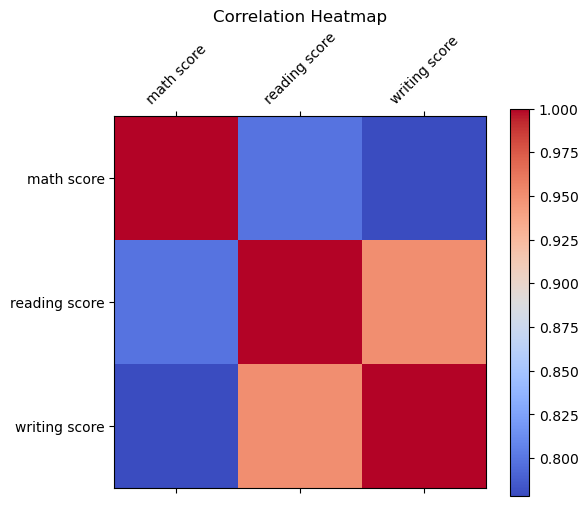


PCA Applied: Reduced to 2 components
Explained Variance Ratio: [0.89563859 0.08785595]

Explanation:
Task 5 checks if numerical features are correlated. PCA is applied only if correlation is strong,
reducing dimensions while preserving most of the variance. If correlation is weak, PCA is skipped.


In [8]:
# === Task 5: Apply PCA if correlated ===
print("\n=== Task 5: Apply PCA if correlated ===")

import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


num_cols = ['math score', 'reading score', 'writing score']


corr_matrix = df_task4[num_cols].corr()
print("\nCorrelation Matrix:")
print(corr_matrix)


plt.figure(figsize=(6,5))
plt.matshow(corr_matrix, fignum=1, cmap='coolwarm')
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)
plt.show()


if (abs(corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)]) > 0.5).any():
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(df_task4[num_cols])
    explained_var = pca.explained_variance_ratio_

    print("\nPCA Applied: Reduced to 2 components")
    print("Explained Variance Ratio:", explained_var)
else:
    print("\nPCA not applied because numerical features are weakly correlated")

print("\nExplanation:")
print("Task 5 checks if numerical features are correlated. PCA is applied only if correlation is strong,")
print("reducing dimensions while preserving most of the variance. If correlation is weak, PCA is skipped.")